<Figure size 1000x800 with 0 Axes>

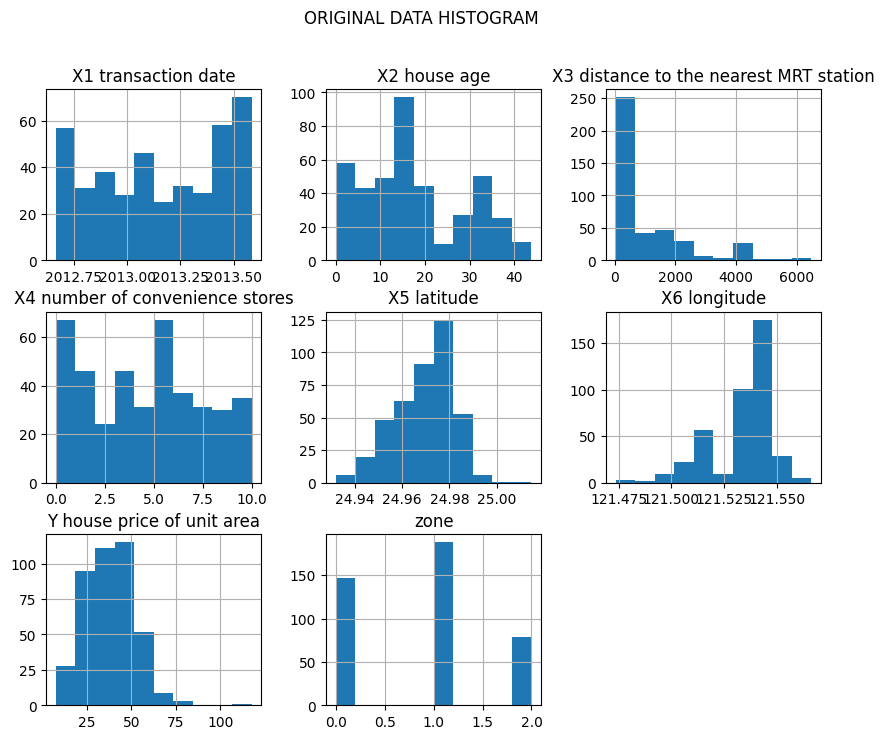

DESCRIPTIVE STATS OF THE ORIGINAL DATA:
       X1 transaction date  X2 house age  X3 distance to the nearest MRT station  \
count                414.0         414.0                                   414.0   
mean                2013.1          17.7                                  1083.9   
std                    0.3          11.4                                  1262.1   
min                 2012.7           0.0                                    23.4   
25%                 2012.9           9.0                                   289.3   
50%                 2013.2          16.1                                   492.2   
75%                 2013.4          28.1                                  1454.3   
max                 2013.6          43.8                                  6488.0   

       X4 number of convenience stores  X5 latitude  X6 longitude  Y house price of unit area  \
count                            414.0      4.1e+02       4.1e+02                       414.0   
mean     

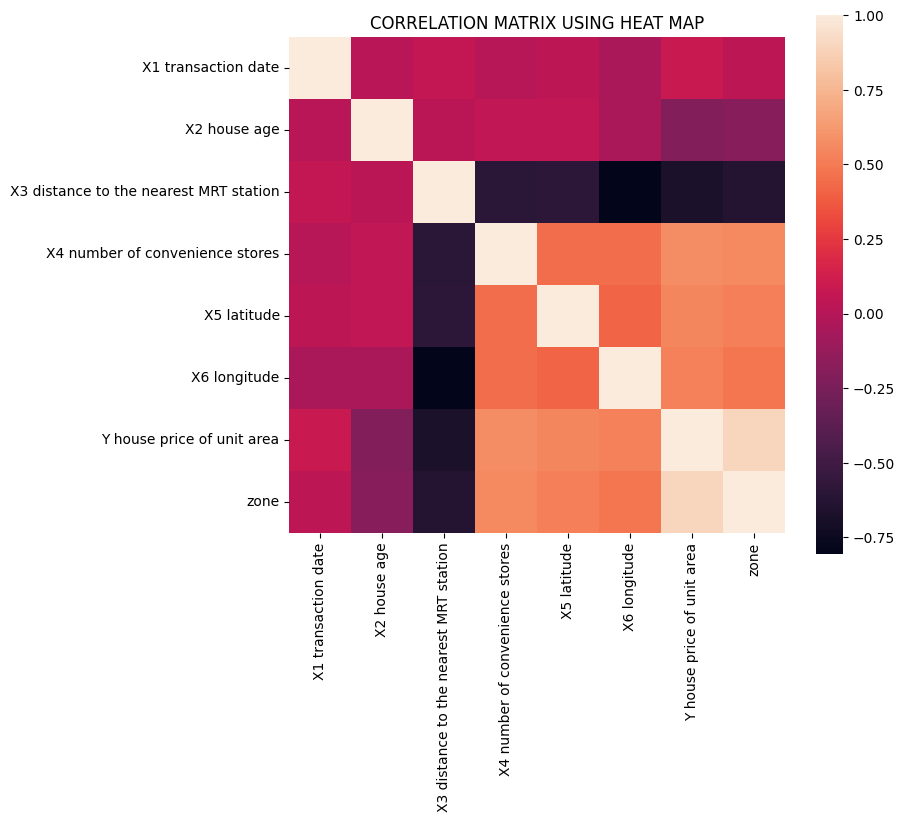

<Figure size 1000x1000 with 0 Axes>

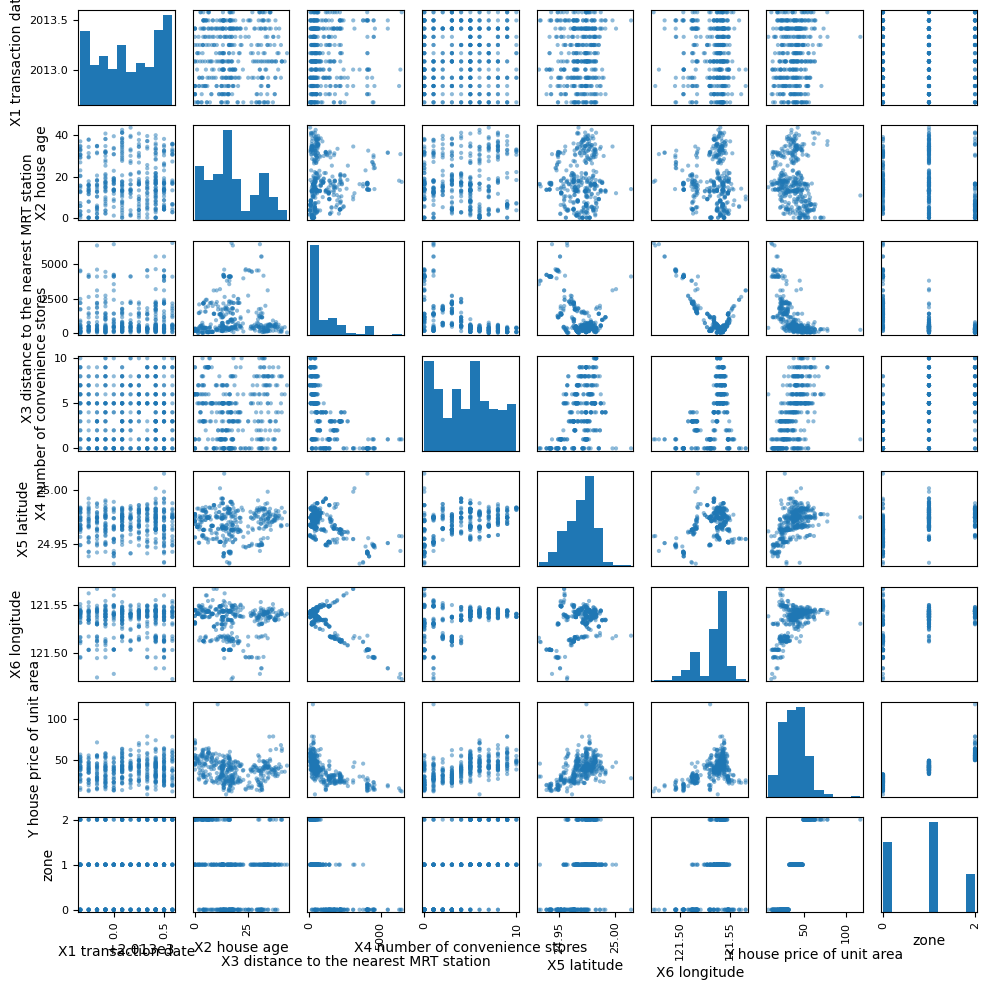

In [56]:
# Part a: EDA of Original Data

from fileinput import filename
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import set_option
from pandas import read_csv
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from numpy import set_printoptions
import seaborn as sns
from pandas.plotting import scatter_matrix

filePath = "/content/sample_data/"
filename = 'real-estate.csv'
data1 = read_csv(filePath+filename)
names = ['No','X1 transaction date','X2 house age', 'X3 distance to the nearest MRT station','X4 number of convenience stores','X5 latitude','X6 longitude','Y house of price of unit area']

df2 = data1.drop(columns=['No'], axis=1)

# RECOMMENDED PART: Mapping the latitude and longitude coordinates to 'zones' to improve model performance

from sklearn.cluster import KMeans

# X5, X6, Y
area_data = df2[['X5 latitude','X6 longitude','Y house price of unit area']]

# group using k mean clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df2['zone'] = kmeans.fit_predict(area_data)
#print(df2[['X5 latitude','X6 longitude', 'zone']])


# save features as pandas dataframe for stepwise feature selection
X1 = df2.drop(['Y house price of unit area'], axis = 1)
Y1 = df2['Y house price of unit area']
X1names = X1.columns

# we look at the distribution of data and its descriptive statistics
plt.figure(figsize=(10,8))
df2.hist(figsize=(10,8))
plt.suptitle("ORIGINAL DATA HISTOGRAM")
plt.show()

# descriptive statistics: mean, max, min, count, 25th percentile, 50th percentile
set_option('display.width', 100)
set_option('display.precision',1)
description = df2.describe()
print(f'DESCRIPTIVE STATS OF THE ORIGINAL DATA:\n{description}')

# correlation heat map, pay attention to the correlation b/w all features and each predictor and the output
plt.figure(figsize=(8,7)) # new plot
corMat = df2.corr(method = 'pearson')
#print(corMat)

# plot correlation matrix as a heat map
sns.heatmap(corMat, square= True)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.title("CORRELATION MATRIX USING HEAT MAP")
plt.show()

# scatter plot of all data
plt.figure(figsize=(10,10))
plt.suptitle("SCATTER MATRIX")
scatter_matrix(df2, figsize=(10,10))
plt.tight_layout()
plt.show()

DESCRIPTIVE STATS OF THE STANDARDIZED DATA: 
       X1 transaction date  X2 house age  X3 distance to the nearest MRT station  \
count              4.1e+02       4.1e+02                                 4.1e+02   
mean               3.7e-13      -9.2e-17                                -1.3e-16   
std                1.0e+00       1.0e+00                                 1.0e+00   
min               -1.7e+00      -1.6e+00                                -8.4e-01   
25%               -8.2e-01      -7.6e-01                                -6.3e-01   
50%                6.4e-02      -1.4e-01                                -4.7e-01   
75%                9.5e-01       9.2e-01                                 2.9e-01   
max                1.5e+00       2.3e+00                                 4.3e+00   

       X4 number of convenience stores  X5 latitude  X6 longitude     zone  \
count                          4.1e+02      4.1e+02       4.1e+02  4.1e+02   
mean                          -7.5e-18    

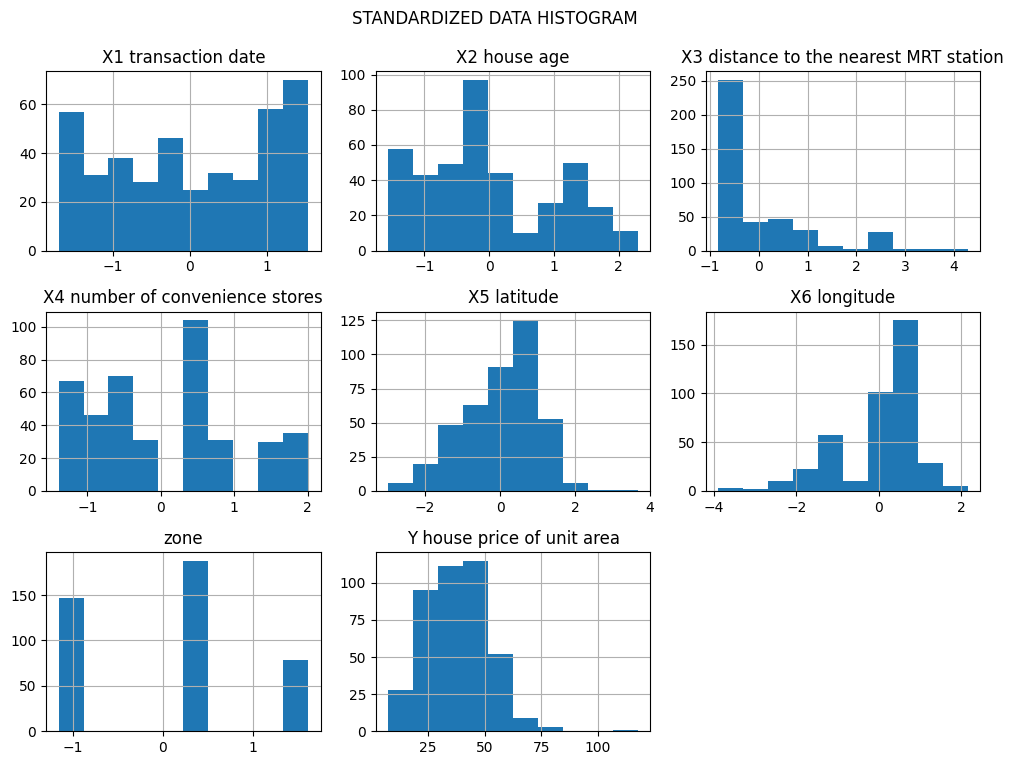

In [57]:
# Part b: Data Preprocessing
"""
Besides the variables X1 (transaction date) and X2 (house age), the rest of
the input variables seem highly correlated with each other and with the output
variable, Y (house price of unit area).

The variables X3, X4, X5, and X6 appear to carry similar weight, yet many of them
have different ranges and and thus scaled differently (except for latitude and longitude,
whose scales are similar). Since I would like to keep the different scales while weighing
the variables similarly, I will use standardization to preprocess the data. This will also
help manage outliers.
"""

# Standardization

scaler1 = StandardScaler().fit(X1)
rescaledX1 = scaler1.transform(X1)

# Summarize transformed data
#set_printoptions(precision=3)
#print(rescaledX1[0:5,:])

# making a new data frame with the standardized data
dataStandDf = pd.DataFrame(rescaledX1, columns = X1names)
dataStandDf['Y house price of unit area'] = Y1.values

# show descriptive statistics after standardization
set_option('display.width', 100)
set_option('display.precision',1)
descriptionStand = dataStandDf.describe()
print(f'DESCRIPTIVE STATS OF THE STANDARDIZED DATA: \n{descriptionStand}')

# Histogram of feature distributions after standardization
dataStandDf.hist(figsize=(10,8))
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("STANDARDIZED DATA HISTOGRAM")
plt.show()

In [58]:
# Part c: Multilinear Regression Model (MLR)

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

# separate features and responses into two different arrays
Y = Y1.values # 1D
X = rescaledX1 # 2D

print("Method - RECURSIVE FEATURE ELIMINATION")
num_features = 4
model = LinearRegression()
rfe = RFE(model, n_features_to_select=num_features)
fit = rfe.fit(X, Y)
print("Num Features: ", fit.n_features_)
print("Selected Features: ", X1names[fit.support_])
print("Feature Ranking: ", fit.ranking_)
# calculate the score for selected features
score = rfe.score(X,Y)

print("Model Score with selected features is: ", score)

Method - RECURSIVE FEATURE ELIMINATION
Num Features:  4
Selected Features:  Index(['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'zone'], dtype='object')
Feature Ranking:  [1 1 1 3 2 4 1]
Model Score with selected features is:  0.8308700692211791


R Squared Scores:
MLR train score: 0.8194846880829789
MLR test score: 0.8511555985438796 

Ridge Regression train score: 0.8232714126286051
Ridge Regression test score: 0.8611043578356127 



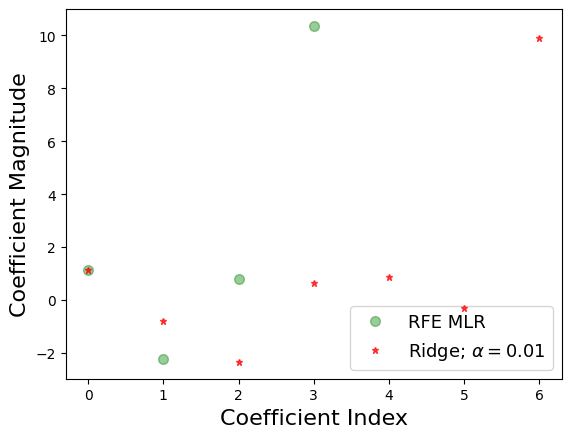

Lasso train score: 0.8069503897254853
Lasso test score: 0.8459555989810043
Number of features used: 5 

Lasso train score (alpha=0.5): 0.81827277571274
Lasso test score (alpha=0.5): 0.8561064396160549
Number of features used (alpha=0.5): 6 

Lasso train score (alpha=0.0001): 0.8232714132168502
Lasso test score (alpha=0.0001): 0.8611038773284088
Number of features used (alpha=0.0001): 7 

MLR train score 0.8194846880829789
MLR test score 0.8511555985438796


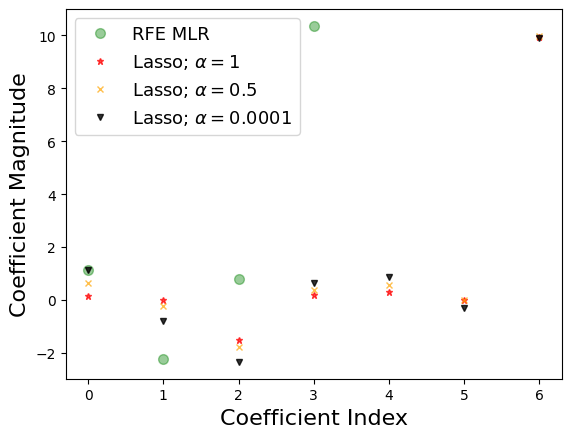

'\nCompared to the RFE MultiLinear Regression Model, the Ridge Regression Model and the Lasso Regression models\nplace more weight on the coefficients of X3, X4, X5, and X6 (i.e. these coefficients have higher absolute values).\n\nBesides the first Lasso Regression model with alpha = 1, all the other Lasso Regression models and the Ridge Regression\nmodel slightly outperform the Multilinear Regression model made with Recursive Feature Elimination.\n'

In [59]:
# Part d: Build a regularized version of the Regression Model

from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import train_test_split

print("R Squared Scores:")

# Ridge Regression

X_train, X_test, y_train, y_test = train_test_split(rescaledX1, Y1, test_size = 0.3,random_state =3)
rfe.fit(X_train, y_train)

rr = Ridge(alpha=0.01)
rr.fit(X_train,y_train)

train_score = rfe.score(X_train,y_train)
test_score = rfe.score(X_test, y_test)

Ridge_train_score = rr.score(X_train,y_train)
Ridge_test_score = rr.score(X_test, y_test)

print("MLR train score:", train_score)
print("MLR test score:", test_score,'\n')
print("Ridge Regression train score:", Ridge_train_score)
print("Ridge Regression test score:", Ridge_test_score,'\n')

# RFE MLR model
plt.plot(rfe.estimator_.coef_,alpha=0.4,linestyle='none',marker='o',markersize=7,color='green',
         label='RFE MLR')
# alpha = 0.01
plt.plot(rr.coef_,alpha=0.7,linestyle='none',marker='*',markersize=5, color='red',
         label=r'Ridge; $\alpha = 0.01$',zorder=7)

plt.xlabel('Coefficient Index', fontsize=16)
plt.ylabel('Coefficient Magnitude', fontsize=16)
plt.legend(fontsize=13,loc=4)
plt.show()

# Lasso Regression
lasso = Lasso()
lasso.fit(X_train, y_train)
lasso_train_score = lasso.score(X_train, y_train)
lasso_test_score = lasso.score(X_test,y_test)
coeff_used = np.sum(lasso.coef_!=0)
print("Lasso train score:", lasso_train_score)
print("Lasso test score:", lasso_test_score)
print("Number of features used:", coeff_used,'\n')

lasso05 = Lasso(alpha=0.5,max_iter=1000000)
lasso05.fit(X_train, y_train)
lasso05_train_score = lasso05.score(X_train, y_train)
lasso05_test_score = lasso05.score(X_test,y_test)
coeff_used05 = np.sum(lasso05.coef_!=0)
print("Lasso train score (alpha=0.5):", lasso05_train_score)
print("Lasso test score (alpha=0.5):", lasso05_test_score)
print("Number of features used (alpha=0.5):", coeff_used05,'\n')

lasso001 = Lasso(alpha=0.0001,max_iter=1000000)
lasso001.fit(X_train, y_train)
lasso001_train_score = lasso001.score(X_train, y_train)
lasso001_test_score = lasso001.score(X_test,y_test)
coeff_used001 = np.sum(lasso001.coef_!=0)

print("Lasso train score (alpha=0.0001):", lasso001_train_score)
print("Lasso test score (alpha=0.0001):", lasso001_test_score)
print("Number of features used (alpha=0.0001):", coeff_used001,'\n')

print("MLR train score",train_score)
print("MLR test score", test_score)

plt.subplot(1,1,1)
# RFE Model
plt.plot(rfe.estimator_.coef_,alpha=0.4,linestyle='none',marker='o',markersize=7,color='green',
         label='RFE MLR')
# alpha = 1
plt.plot(lasso.coef_,alpha=0.7,linestyle='none',marker='*',markersize=5,color='red',
         label = r'Lasso; $\alpha = 1$',zorder=7)
# alpha = 0.5
plt.plot(lasso05.coef_,alpha=0.7,linestyle='none',marker='x',markersize=5,color='orange',
         label = r'Lasso; $\alpha = 0.5$',zorder=7)
# alpha = 0.0001
plt.plot(lasso001.coef_,alpha=0.8,linestyle='none',marker='v',markersize=4,color='black',
         label = r'Lasso; $\alpha = 0.0001$',zorder=7)


plt.xlabel('Coefficient Index',fontsize=16)
plt.ylabel('Coefficient Magnitude',fontsize=16)
plt.legend(fontsize=13,loc='best')
plt.show()

"""
Compared to the RFE MultiLinear Regression Model, the Ridge Regression Model and the Lasso Regression models
place more weight on the coefficients of X3, X5, and X6 (i.e. these coefficients have higher absolute values).

Besides the Lasso Regression models with alpha = 1 and alpha = 0.5, the other Lasso Regression model (alpha = 0.0001) and the Ridge Regression
model slightly outperform the Multilinear Regression model made with Recursive Feature Elimination.
"""

In [60]:
# Part e: Using SVR and Ensemble Models

# Using Support Vector Machines (SVR)

from sklearn.svm import SVR, LinearSVR
from sklearn.metrics import r2_score, mean_squared_error

print("Negative MSE (higher values are better):")

svr = LinearSVR(epsilon=1.5, random_state=42)
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
# determine score for the bagging method
print(f'SVR: -{mean_squared_error(y_test, y_pred_svr)}')

kernelSvr = SVR(kernel="rbf", degree = 3, C = 70.0) # did some tuning and C = 70.0 seemed to be best for reducing MSE
kernelSvr.fit(X_train, y_train)
y_pred_kSvr = kernelSvr.predict(X_test)
# determine score for the kernel SVR method
print(f'Kernel SVR: -{mean_squared_error(y_test, y_pred_kSvr)}')

# Using Ensemble Techniques (Random Forest, Bagging, AdaBoost)

from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import RandomForestRegressor

# Random Forest (max_depth = 2)

rnd_clf = RandomForestRegressor(n_estimators=500, max_depth = 2, n_jobs=-1,
random_state=42)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)
print(f'Random Forest: -{mean_squared_error(y_test,y_pred_rf)}')

# Bagging Regressor
bag_clf = BaggingRegressor(
DecisionTreeRegressor(random_state=42), n_estimators=500,
max_samples=100, bootstrap=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)
# determine score for the bagging method
print(f'Bagging Regressor: -{mean_squared_error(y_test, y_pred_bag)}')

# AdaBoost Regressor
ada_clf = AdaBoostRegressor(
DecisionTreeRegressor(max_depth=6), n_estimators=80, learning_rate=0.75, random_state=42)
ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)
print(f'AdaBoost Regressor: -{mean_squared_error(y_test, y_pred_ada)}')

Negative MSE (higher values are better):
SVR: -27.023440640297064
Kernel SVR: -20.676535944435617
Random Forest: -26.038939308017063
Bagging Regressor: -25.549832893206627
AdaBoost Regressor: -53.34828266432773


SVR: -33.658400 (40.999743)
KernSVR: -31.327645 (39.499566)
RFE: -33.709762 (37.226673)
ridge: -31.868495 (37.887212)
lasso(1): -35.138891 (39.298768)
lasso(0.5): -32.777158 (38.394625)
lasso(0.0001): -31.868437 (37.886217)
rnd: -32.382148 (34.531520)
bag: -29.299709 (33.888915)
ada: -48.053945 (49.687902)


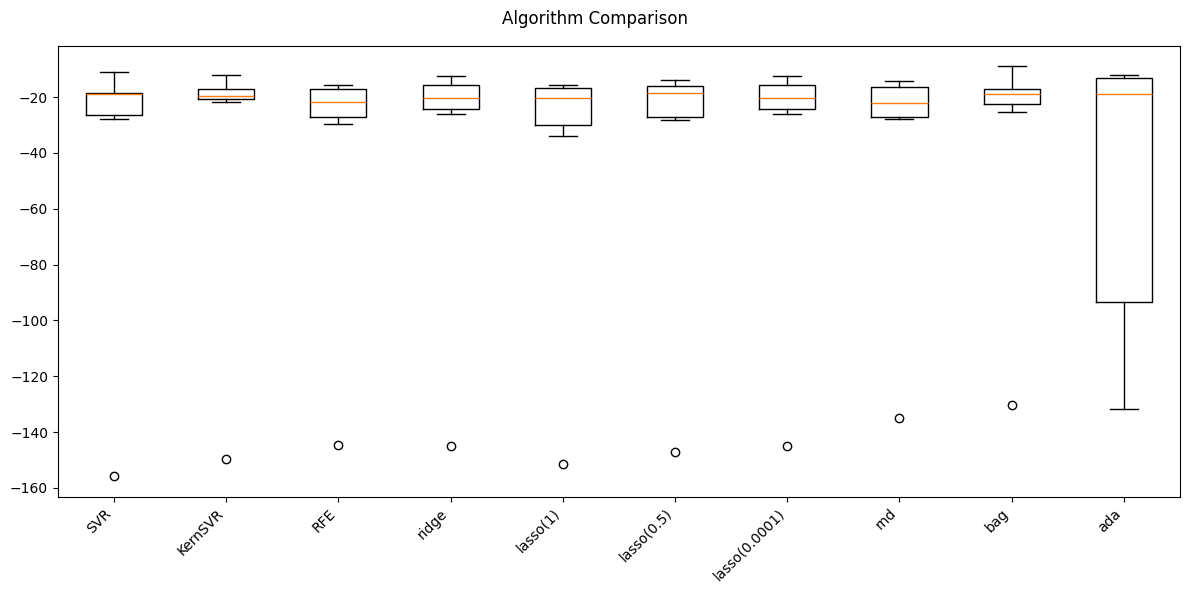

'\nSince the number of folds used for cross validation was k = 10, I can assume that the test error rates have neither very high bias nor\nhigh variance, so the results from cross validation should be reliable to use for algorithm comparison.\n\nBased on the cross validation results, the best algorithm for the Real Estate Machine Learning model appears to be the Bagging Regressor, as it has\nthe lowest Mean Squared Error (least bias), with the Kernel SVR algorithm coming in at a close second. The interquartile ranges on the boxplot charts also\nvisually indicate that the Bagging Regressor has the second-lowest variance, second to the AdaBoost Regressor.\n\nBootstrap aggregating being the best algorithm makes sense since it is based on sampling with replacement, which leaves for overlap between training\nand testing data. However, the cross validation technique prohibits any overlap between the training and testing data, thus ensuring that the bagging\nregressor really is the best choic

In [61]:
# Part f: Cross Validation of All Models

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from matplotlib import pyplot

models = []

models.append(('SVR', svr))
models.append(('KernSVR', kernelSvr))
models.append(("RFE", rfe))
models.append(("ridge", rr))
models.append(("lasso(1)",lasso))
models.append(("lasso(0.5)",lasso05))
models.append(("lasso(0.0001)",lasso001))
models.append(("rnd", rnd_clf))
models.append(("bag", bag_clf))
models.append(("ada", ada_clf))

results = []
names = []


for name, mod in models:
  kfold = KFold(n_splits = 10, random_state = 7, shuffle = True)
  cv_results = cross_val_score(mod, rescaledX1, Y1, cv = kfold, scoring = 'neg_mean_squared_error') # higher negative MSE means lower MSE
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

# boxplot algorithm comparison
fig = pyplot.figure(figsize=(12,6))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names, rotation=45, ha='right')
pyplot.tight_layout()
pyplot.show()

# Part g: Justification of Answer
"""
Since the number of folds used for cross validation was k = 10, I can assume that the test error rates have neither very high bias nor
high variance, so the results from cross validation should be reliable to use for algorithm comparison.

Based on the cross validation results, the Bagging Regressor has the lowest Mean Squared Error (least bias) and the second-lowest variance, while the Kernel SVR algorithm has the second-lowest MSE and the lowest variance.
The interquartile ranges on the boxplot charts also visually indicate that the Bagging Regressor has the second-lowest variance, second to the Kern SVR Model.

Since greater consistency with results is more important than a slight increase in performance, reducing variance should be prioritized. That is why I have decided that the best algorithm for the Real Estate Machine Learning
model is the Kernel SVR Model. It came in a very close second to Bagging in terms of lowest MSE, and its range and interquartile range are noticeably smaller, as seen from the boxplot charts.
"""